#  Pertemuan 2:  Data Preprocessing dan EDA

**Nama:** Andi Mawadda Taiba 
**NIM:** 105841103623
**Kelas:** 5A Applied Machine Learning
**Tanggal:** 14 Maret - 2026

> Pastikan semua cell sudah dijalankan dan tidak ada error.

# 1. TUJUAN PRATIKUM 
Praktikum ini bertujuan untuk memahami proses awal dalam analisis data sebelum membangun model machine learning. Pada tahap ini mahasiswa mempelajari bagaimana cara menyiapkan data agar lebih bersih, terstruktur, dan siap dianalisis. Proses yang dilakukan meliputi pemeriksaan struktur dataset, identifikasi nilai yang hilang, penanganan outlier pada beberapa variabel numerik, serta melakukan proses normalisasi atau standardisasi pada data. Selain itu, praktikum ini juga bertujuan untuk melatih kemampuan eksplorasi data menggunakan visualisasi sehingga pola dan hubungan antar variabel dapat dipahami dengan lebih baik sebelum dilakukan tahap pemodelan.

# 2 Dataset yang Digunakan

Dataset yang digunakan dalam praktikum ini adalah Students Performance in Exams Dataset yang diperoleh dari platform Kaggle. Dataset ini berisi informasi mengenai performa akademik siswa berdasarkan beberapa faktor seperti jenis kelamin, latar belakang pendidikan orang tua, jenis makan siang yang diterima, serta keikutsertaan dalam kursus persiapan ujian.

Sumber dataset:
https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

# 3. Langkah Kerja Praktikum

- Menyiapkan lingkungan kerja dengan mengimpor library Python yang dibutuhkan seperti pandas, numpy, seaborn, matplotlib, dan scikit-learn untuk proses analisis dan visualisasi data.
- Mengunduh dataset Students Performance in Exams dari platform Kaggle kemudian memuat dataset tersebut ke dalam Python menggunakan library pandas.
- Menampilkan beberapa baris pertama dataset untuk memahami struktur awal data serta mengetahui nama kolom yang tersedia.
- Memeriksa ukuran dataset untuk mengetahui jumlah baris dan kolom yang terdapat pada data.
- Mengidentifikasi tipe data pada setiap variabel untuk mengetahui apakah data tersebut termasuk numerik atau kategorikal.
- Melakukan pengecekan terhadap kemungkinan adanya missing value pada dataset.
- Melakukan proses pembersihan data jika ditemukan nilai yang hilang atau data yang tidak sesuai.
- Mengidentifikasi kemungkinan adanya outlier pada variabel numerik menggunakan metode Interquartile Range (IQR).
- Membatasi nilai ekstrem pada beberapa kolom numerik agar distribusi data menjadi lebih stabil.
- Melakukan proses scaling pada variabel numerik menggunakan metode StandardScaler untuk menyesuaikan skala antar variabel.
- Melakukan Exploratory Data Analysis (EDA) dengan membuat beberapa visualisasi data untuk memahami pola distribusi dan hubungan antar variabel.
- Menganalisis hasil visualisasi yang diperoleh untuk menemukan pola atau informasi penting dari dataset.
- Menuliskan beberapa insight atau kesimpulan awal berdasarkan hasil eksplorasi data yang telah dilakukan.

# IMPORT LIBRARY
- import pandas as pd
Digunakan untuk memanggil library pandas dengan nama singkat pd. Library ini berfungsi untuk membaca, menampilkan, dan mengolah data dalam bentuk tabel.
- import numpy as np
Digunakan untuk memanggil library numpy dengan nama singkat np. Library ini membantu proses perhitungan numerik dan pengolahan array.
- import matplotlib.pyplot as plt
Digunakan untuk membuat grafik dasar seperti histogram, diagram batang, dan pengaturan tampilan visualisasi.
- import seaborn as sns
Digunakan untuk membuat visualisasi data yang lebih menarik dan lebih mudah dibaca, misalnya boxplot, violin plot, scatter plot, dan heatmap.
- from sklearn.preprocessing import StandardScaler
Digunakan untuk mengambil class StandardScaler dari library scikit-learn. Fungsi ini dipakai untuk melakukan standardisasi data numerik agar memiliki skala yang sebanding.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Membaca Dataset
- pd.read_csv("StudentsPerformance.csv")
Digunakan untuk membaca file dataset berformat CSV yang bernama StudentsPerformance.csv.
Hasil pembacaan data disimpan ke dalam variabel df.
Variabel df biasanya dipakai sebagai singkatan dari dataframe, yaitu bentuk tabel data pada pandas.
- df.head()
Digunakan untuk menampilkan 5 baris pertama dataset. Tujuannya agar bisa melihat isi awal data, nama kolom, dan bentuk setiap nilai yang ada.

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Menampilkan Ukuran Dataset
- df.shape
Digunakan untuk mengetahui ukuran dataset.

Output dari perintah ini berupa dua angka:

jumlah baris

jumlah kolom

Dengan perintah ini, praktikan dapat mengetahui seberapa besar data yang sedang digunakan.

In [3]:
print("Ukuran data:", df.shape)
print("\nTipe data:")
print(df.dtypes)

Ukuran data: (1000, 8)

Tipe data:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


# Mengecek Missing Value
- df.isnull()
Digunakan untuk memeriksa apakah ada nilai kosong pada dataset.
- .sum()
Digunakan untuk menjumlahkan banyaknya nilai kosong pada setiap kolom.
Hasilnya menunjukkan jumlah missing value per kolom.
> Jika semua hasil bernilai 0, berarti dataset tidak memiliki data yang hilang.

In [4]:
print("\nMissing value:")
print(df.isnull().sum())


Missing value:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


# Membuat Fungsi Penanganan Outlier
- def batasi_outlier_iqr(data, kolom):
Digunakan untuk membuat fungsi bernama batasi_outlier_iqr. Fungsi ini bertujuan menangani outlier pada kolom tertentu.
- q1 = data[kolom].quantile(0.25)
Menghitung kuartil pertama atau batas 25% data.
- q3 = data[kolom].quantile(0.75)
Menghitung kuartil ketiga atau batas 75% data.
- iqr = q3 - q1
Menghitung Interquartile Range, yaitu jarak antara kuartil ketiga dan kuartil pertama.
- batas_bawah = q1 - 1.5 * iqr
Menentukan batas bawah untuk mendeteksi nilai yang terlalu kecil.
- batas_atas = q3 + 1.5 * iqr
Menentukan batas atas untuk mendeteksi nilai yang terlalu besar.
- data[kolom] = data[kolom].clip(batas_bawah, batas_atas)
Digunakan untuk memotong nilai yang berada di luar batas bawah dan batas atas agar masuk ke rentang yang wajar.
- return data
Mengembalikan dataframe yang sudah diperbaiki.

Baris pertama digunakan untuk menangani outlier pada kolom math_score.

Baris kedua digunakan untuk menangani outlier pada kolom reading_score.

Hasil perbaikan disimpan kembali ke df agar data yang digunakan berikutnya adalah data yang sudah dibersihkan dari nilai ekstrem.

Pemilihan dua kolom ini sudah memenuhi syarat tugas karena diminta menangani outlier minimal pada dua kolom numerik.

In [5]:
def batasi_outlier_iqr(data, kolom):
    q1 = data[kolom].quantile(0.25)
    q3 = data[kolom].quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    data[kolom] = data[kolom].clip(batas_bawah, batas_atas)
    return data

df = batasi_outlier_iqr(df, "math score")
df = batasi_outlier_iqr(df, "reading score")

# Melakukan Scaling Data
- scaler = StandardScaler()
Membuat objek scaler dari StandardScaler.
- kolom_numerik = ["math_score", "reading_score", "writing_score"]
Membuat daftar kolom numerik yang akan diubah skalanya.
- scaler.fit_transform(df[kolom_numerik])
Digunakan untuk:
mempelajari distribusi data

lalu langsung mengubah data ke bentuk standar

Standardisasi membuat data memiliki:

rata-rata mendekati 0

standar deviasi mendekati 1

Hasil scaling kemudian disimpan kembali ke kolom numerik yang sama.

In [6]:
scaler = StandardScaler()
kolom_numerik = ["math score", "reading score", "writing score"]

df[kolom_numerik] = scaler.fit_transform(df[kolom_numerik])
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,0.391218,0.193085,0.391492
1,female,group C,some college,standard,completed,0.190078,1.434787,1.313269
2,female,group B,master's degree,standard,none,1.598061,1.779704,1.642475
3,male,group A,associate's degree,free/reduced,none,-1.284952,-0.841667,-1.583744
4,male,group C,some college,standard,none,0.659405,0.606986,0.457333


# Menampilkan Distribusi Gender

- df["gender"].value_counts()
Menghitung jumlah data pada setiap kategori gender.

- .sort_values()
Mengurutkan hasil perhitungan agar tampil lebih rapi.

- plt.figure(figsize=(7,4))
Mengatur ukuran grafik agar proporsional.

- plt.barh(gender_count.index, gender_count.values)
Membuat diagram batang horizontal berdasarkan jumlah siswa pada masing-masing gender.

- plt.title(...)
Memberi judul grafik.

- plt.xlabel(...)
Memberi label sumbu horizontal.

- plt.ylabel(...)
Memberi label sumbu vertikal.

- plt.show()
Menampilkan grafik ke layar.

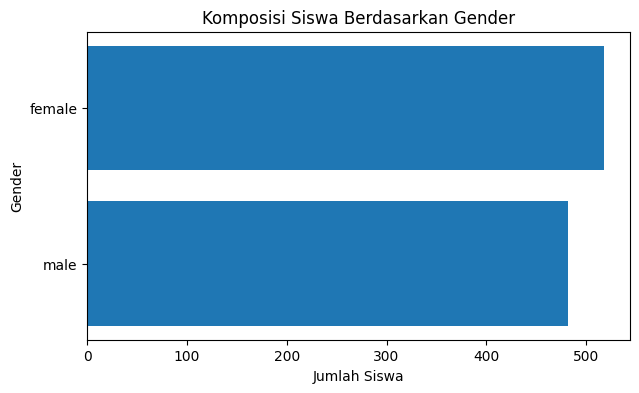

In [7]:
gender_count = df["gender"].value_counts().sort_values()

plt.figure(figsize=(7,4))
plt.barh(gender_count.index, gender_count.values)
plt.title("Komposisi Siswa Berdasarkan Gender")
plt.xlabel("Jumlah Siswa")
plt.ylabel("Gender")
plt.show()

# Menampilkan Histogram Math Score

- plt.hist(df["math_score"], bins=20, edgecolor="black")
Membuat histogram untuk melihat sebaran nilai matematika.

- bins=20
Menentukan jumlah interval batang pada histogram.

- edgecolor="Green"
Memberi garis tepi Hijau pada setiap batang agar lebih jelas.

- plt.axvline(df["math_score"].mean(), ...)
Menambahkan garis vertikal pada posisi rata-rata nilai matematika.

- linestyle="--"
Membuat garis putus-putus.

- linewidth=2
Mengatur ketebalan garis.

- label="Rata-rata"
Memberi keterangan pada garis.

- plt.legend()
Menampilkan legenda grafik.

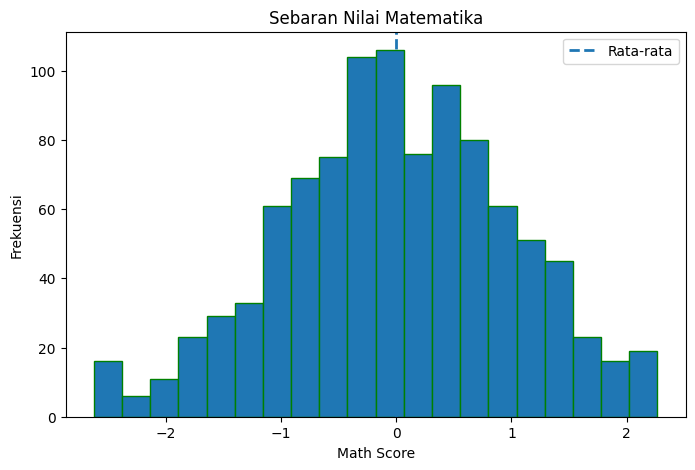

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["math score"], bins=20, edgecolor="green")
plt.axvline(df["math score"].mean(), linestyle="--", linewidth=2, label="Rata-rata")
plt.title("Sebaran Nilai Matematika")
plt.xlabel("Math Score")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

# Menampilkan Violin Plot

- sns.violinplot(...)
Digunakan untuk melihat distribusi data numerik pada tiap kategori.

- x="gender"
Menentukan bahwa kategori pada sumbu horizontal adalah gender.

- y="writing_score"
Menentukan bahwa nilai yang dibandingkan adalah writing score.

Grafik ini memperlihatkan:

bentuk distribusi

penyebaran nilai

kecenderungan nilai pada masing-masing kelompok

Grafik ini berguna untuk membandingkan pola nilai menulis antara siswa laki-laki dan perempuan.

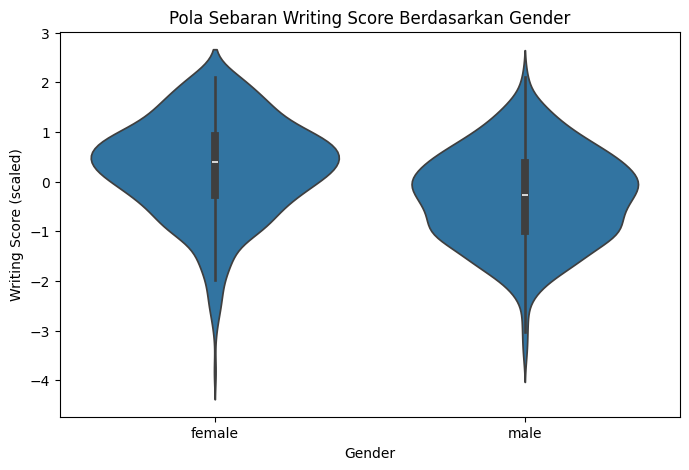

In [9]:
plt.figure(figsize=(8,5))
sns.violinplot(x="gender", y="writing score", data=df)
plt.title("Pola Sebaran Writing Score Berdasarkan Gender")
plt.xlabel("Gender")
plt.ylabel("Writing Score (scaled)")
plt.show()

# Menampilkan Boxplot

- sns.boxplot(...)
Digunakan untuk melihat ringkasan distribusi data berdasarkan kategori.

- Boxplot menunjukkan:

median

kuartil

rentang data

kemungkinan outlier

- x="lunch"
Menentukan kategori pada sumbu horizontal, yaitu jenis lunch.

- y="math_score"
Menentukan nilai yang dibandingkan, yaitu math score.

- plt.xticks(rotation=10)
Memutar sedikit label pada sumbu x agar lebih mudah dibaca.

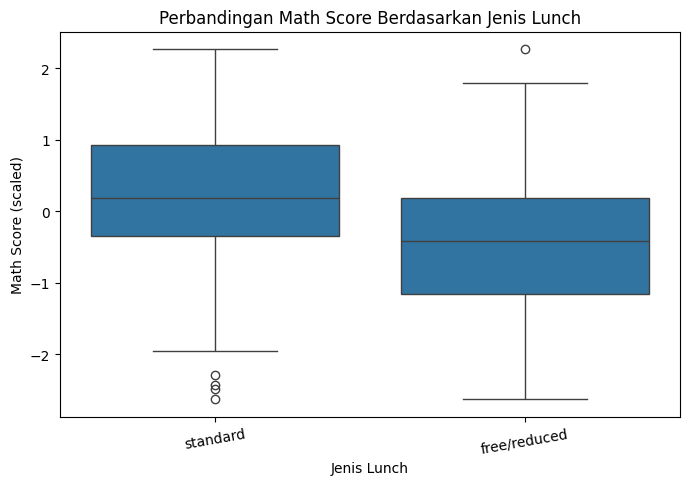

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x="lunch", y="math score", data=df)
plt.title("Perbandingan Math Score Berdasarkan Jenis Lunch")
plt.xlabel("Jenis Lunch")
plt.ylabel("Math Score (scaled)")
plt.xticks(rotation=10)
plt.show()

# Menampilkan Scatter Plot

- sns.scatterplot(...)
Digunakan untuk melihat hubungan antara dua variabel numerik.

- x="reading_score"
Variabel pada sumbu horizontal adalah reading score.

- y="writing_score"
Variabel pada sumbu vertikal adalah writing score.

- hue="gender"
Memberikan warna berbeda berdasarkan gender agar pola tiap kelompok lebih mudah diamati.

Grafik ini membantu melihat apakah siswa dengan nilai membaca tinggi juga cenderung memiliki nilai menulis tinggi.

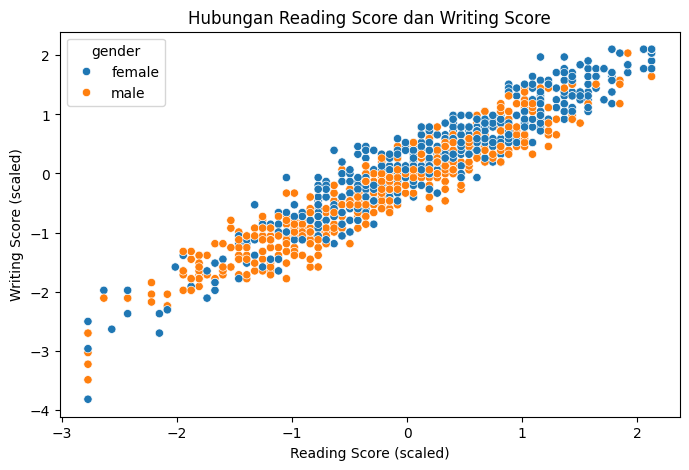

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="reading score", y="writing score", hue="gender", data=df)
plt.title("Hubungan Reading Score dan Writing Score")
plt.xlabel("Reading Score (scaled)")
plt.ylabel("Writing Score (scaled)")
plt.show()

# Menampilkan Heatmap Korelasi
- df[kolom_numerik].corr()
Menghitung korelasi antar kolom numerik.

- sns.heatmap(...)
Menampilkan hasil korelasi dalam bentuk peta warna.

- annot=True
Menampilkan angka korelasi pada setiap kotak.

- cmap="coolwarm"
Menentukan gradasi warna pada heatmap.

- fmt=".2f"
Menampilkan angka korelasi dengan dua angka di belakang koma.

Grafik ini membantu melihat seberapa kuat hubungan antara:

math score

reading score

writing score

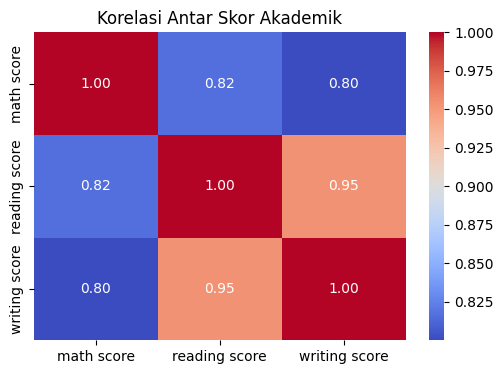

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df[kolom_numerik].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Skor Akademik")
plt.show()

# Menampilkan Rata-rata Nilai Berdasarkan Pendidikan Orang Tua

- df.groupby("parent_education")["math_score"].mean()
Mengelompokkan data berdasarkan pendidikan orang tua, lalu menghitung rata-rata math score tiap kelompok.

- .sort_values()
Mengurutkan hasil rata-rata dari kecil ke besar.

- plt.barh(...)
Menampilkan hasil dalam bentuk diagram batang horizontal.

Grafik ini memudahkan untuk membandingkan rata-rata nilai matematika siswa berdasarkan latar belakang pendidikan orang tua.

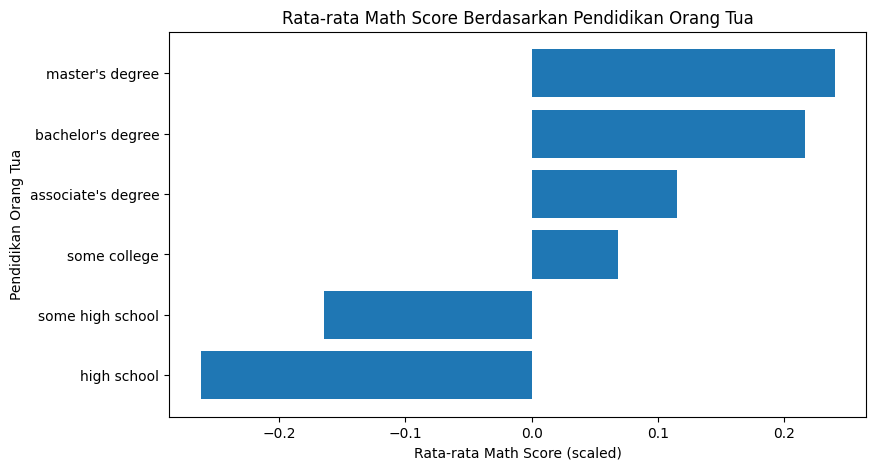

In [13]:
rata_math = df.groupby("parental level of education")["math score"].mean().sort_values()

plt.figure(figsize=(9,5))
plt.barh(rata_math.index, rata_math.values)
plt.title("Rata-rata Math Score Berdasarkan Pendidikan Orang Tua")
plt.xlabel("Rata-rata Math Score (scaled)")
plt.ylabel("Pendidikan Orang Tua")
plt.show()

# Visualisasi Data

Untuk memahami pola dan hubungan antar variabel dalam dataset, dilakukan beberapa visualisasi data. Pada praktikum ini dibuat tujuh visualisasi yang menggambarkan distribusi data, perbandingan antar kategori, serta hubungan antar variabel numerik.

Visualisasi yang digunakan meliputi:

1. Grafik distribusi jumlah siswa berdasarkan gender.
2. Histogram untuk melihat sebaran nilai matematika.
3. Violin plot untuk membandingkan writing score berdasarkan gender.
4. Boxplot untuk melihat perbandingan math score berdasarkan jenis lunch.
5. Scatter plot untuk melihat hubungan antara reading score dan writing score.
6. Heatmap korelasi untuk melihat hubungan antar skor akademik.
7. Diagram batang rata-rata math score berdasarkan pendidikan orang tua.


# INSIGHT

1. Distribusi siswa berdasarkan gender menunjukkan bahwa jumlah siswa laki-laki dan perempuan relatif seimbang dalam dataset.
2. Sebaran nilai matematika menunjukkan bahwa sebagian besar siswa memiliki nilai pada rentang menengah, dengan hanya sedikit siswa yang berada pada nilai sangat rendah atau sangat tinggi.
3. Pola distribusi writing score antara siswa laki-laki dan perempuan menunjukkan adanya perbedaan penyebaran nilai pada kedua kelompok tersebut.
4. Hasil boxplot menunjukkan adanya perbedaan performa matematika pada kelompok siswa berdasarkan jenis lunch yang mereka terima.
5. Scatter plot antara reading score dan writing score memperlihatkan hubungan positif, yang berarti siswa dengan kemampuan membaca yang baik cenderung juga memiliki kemampuan menulis yang baik.
6. Heatmap korelasi menunjukkan bahwa ketiga skor akademik memiliki hubungan yang cukup kuat satu sama lain.
7. Rata-rata nilai matematika siswa menunjukkan variasi berdasarkan latar belakang pendidikan orang tua, yang dapat menjadi salah satu faktor yang mempengaruhi performa akademik siswa.